In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/drgfreeman/rockpaperscissors/README_rpc-cv-images.txt
/kaggle/input/datasets/drgfreeman/rockpaperscissors/paper/cQ0dBO3yHPohZ9U9.png
/kaggle/input/datasets/drgfreeman/rockpaperscissors/paper/jAh36hlZLpECSBHp.png
/kaggle/input/datasets/drgfreeman/rockpaperscissors/paper/QnjBVl6cFnyd2hVF.png
/kaggle/input/datasets/drgfreeman/rockpaperscissors/paper/dZh2VMRu9nRGHhYL.png
/kaggle/input/datasets/drgfreeman/rockpaperscissors/paper/SDQQfzHl47yNqA6K.png
/kaggle/input/datasets/drgfreeman/rockpaperscissors/paper/E10FR2TKbBsv9Hgm.png
/kaggle/input/datasets/drgfreeman/rockpaperscissors/paper/BoMfAmQYWtoiGHBV.png
/kaggle/input/datasets/drgfreeman/rockpaperscissors/paper/AfvIbTwxuG0q7Ij1.png
/kaggle/input/datasets/drgfreeman/rockpaperscissors/paper/41HC0VBlHSRhi0AG.png
/kaggle/input/datasets/drgfreeman/rockpaperscissors/paper/gpipGA62xfMjfr8O.png
/kaggle/input/datasets/drgfreeman/rockpaperscissors/paper/9rwmakEj6Wg1YQWW.png
/kaggle/input/datasets/drgfreeman/rockpaperscissors/pa

In [2]:
import torch 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn 
import torch.optim as optim

from torchvision import datasets , transforms
from torch.utils.data import DataLoader

In [3]:
import os
import shutil

base_path = "/kaggle/working/rps_clean"

os.makedirs(base_path, exist_ok=True)

In [4]:
source_path = "/kaggle/input/datasets/drgfreeman/rockpaperscissors"

for folder in ["rock", "paper", "scissors"]:
    shutil.copytree(
        os.path.join(source_path, folder),
        os.path.join(base_path, folder),
        dirs_exist_ok=True
    )

In [5]:
### transformation for image 
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    # transforms.Normalize((0.5,), (0.5,)) # Optional: helps model learn faster
])

In [6]:
dataset = datasets.ImageFolder(base_path, transform=transform)

In [7]:
print(dataset.classes)

['paper', 'rock', 'scissors']


In [8]:
# Split and train & test method .. we gonna use 80-20 rule 

train_size = int(0.8* len(dataset))
test_size = len(dataset) - train_size

train_data , test_data = torch.utils.data.random_split(dataset, [train_size, test_size])

In [9]:
# Data Loader --> split data into train_data , test_data .. now need to put them on "conveyor belt"
# so model can eat them in small bites

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size= 32, shuffle=False)


print(f"Check: We have {len(train_loader)} batches of 32 images each.")

Check: We have 55 batches of 32 images each.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.5529412].


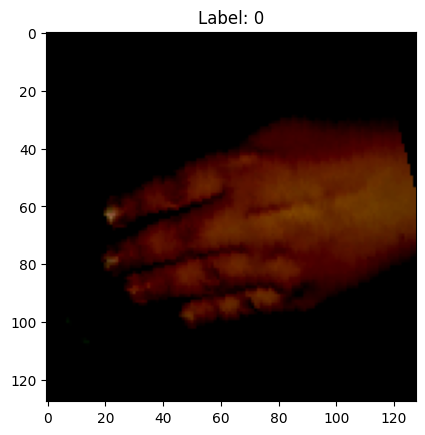

In [10]:
# Visualize 

import matplotlib.pyplot as plt

# Get one batch of images
images, labels = next(iter(train_loader))

# Show the first image in the batch
plt.imshow(images[0].permute(1, 2, 0)) # Rearrange dimensions for plotting
plt.title(f"Label: {labels[0]}")
plt.show()

In [ ]:
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1) # mean take a color image (3 channels) look at it through 16 different 
# 3x3 magnifying glasses and add a 1-piexl border .. so resulting image doesn't get smaller
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, 3 , padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64 * 16 * 16, 128)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

model = CNN()

In [12]:
# loss + optimizer 

criterion = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(), lr=0.001)

In [13]:
import torch
import numpy as np
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

epochs = 15

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

Epoch 1, Loss: 54.8993
Epoch 2, Loss: 26.0246
Epoch 3, Loss: 14.0314
Epoch 4, Loss: 9.4699
Epoch 5, Loss: 6.8555
Epoch 6, Loss: 7.6684
Epoch 7, Loss: 6.2791
Epoch 8, Loss: 4.2184
Epoch 9, Loss: 3.5489
Epoch 10, Loss: 3.6644
Epoch 11, Loss: 4.0131
Epoch 12, Loss: 2.4905
Epoch 13, Loss: 3.8738
Epoch 14, Loss: 1.8580
Epoch 15, Loss: 1.7337


In [14]:
# Evaluation Test accuracy 

model.eval 
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs , 1) # look at the 3 score my mdoel gave me , ignore how the score is and just tell 
# me the index number (predicted) of the winner
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Accuracy: {100 * correct / total:.2f}%")

Accuracy: 98.17%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.5058824].


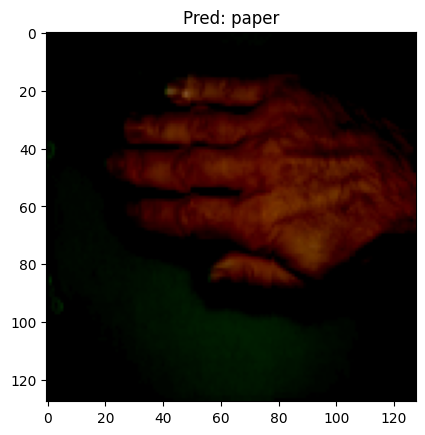

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


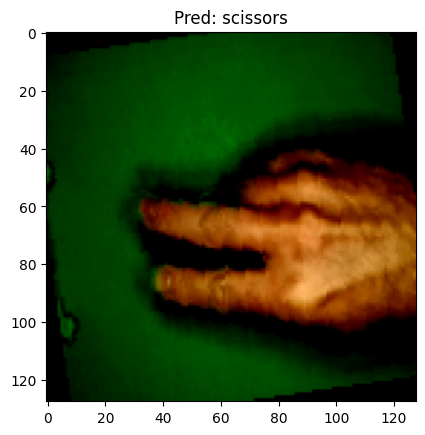

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.62352943].


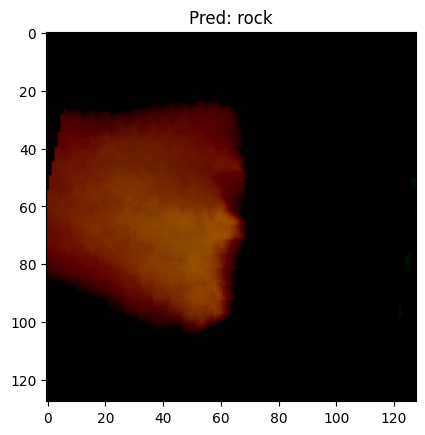

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8039216].


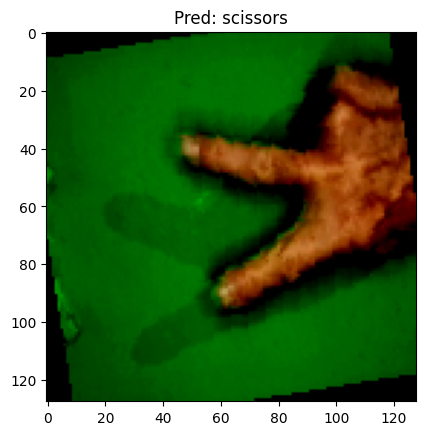

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.58431375].


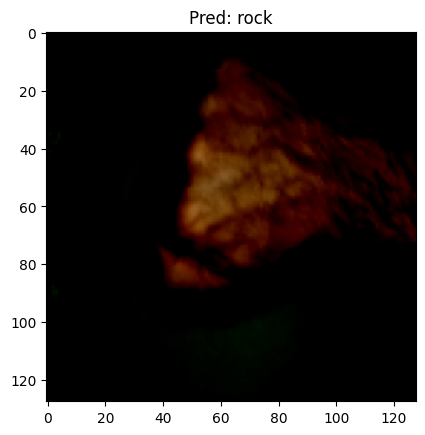

In [15]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))

outputs = model(images)
_, preds = torch.max(outputs, 1)

for i in range(5):
    plt.imshow(images[i].permute(1,2,0))
    plt.title(f"Pred: {dataset.classes[preds[i]]}")
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.96862745].


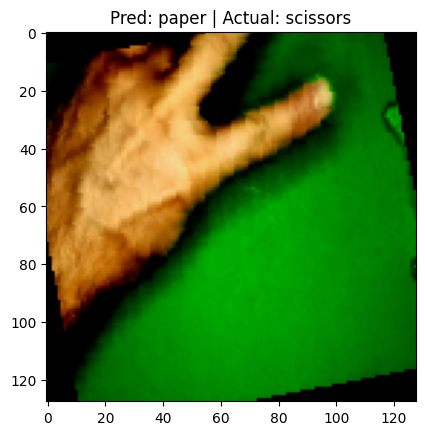

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9372549..0.5764706].


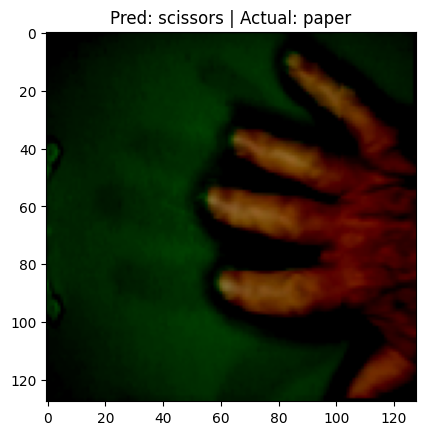

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.92941177..0.48235297].


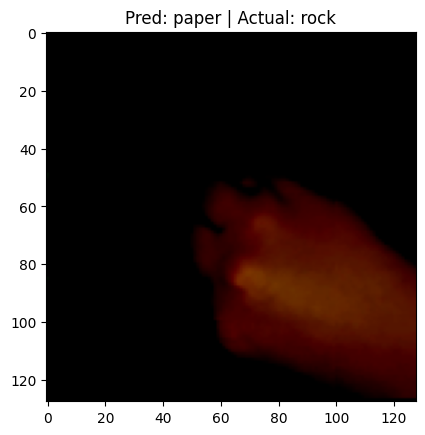

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.654902].


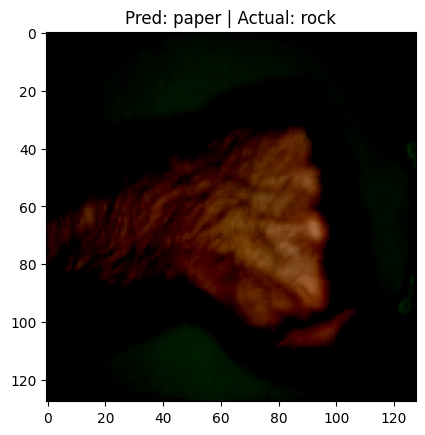

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


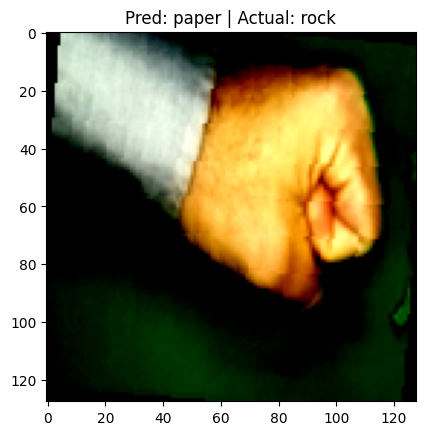

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


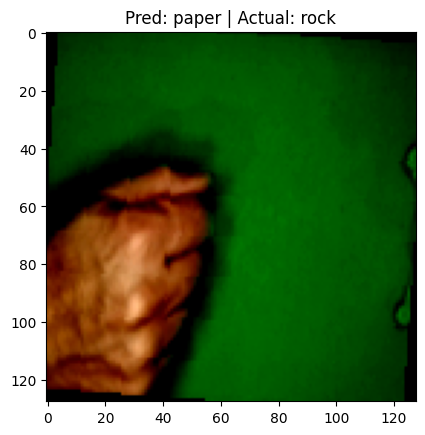

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


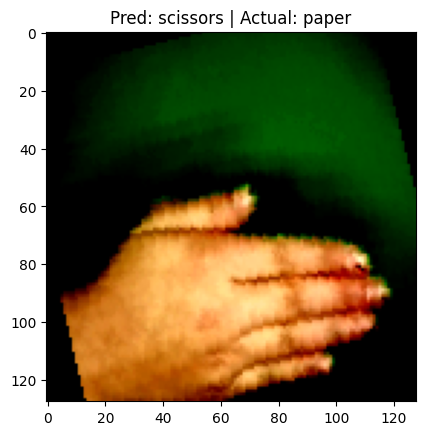

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8666667..0.9529412].


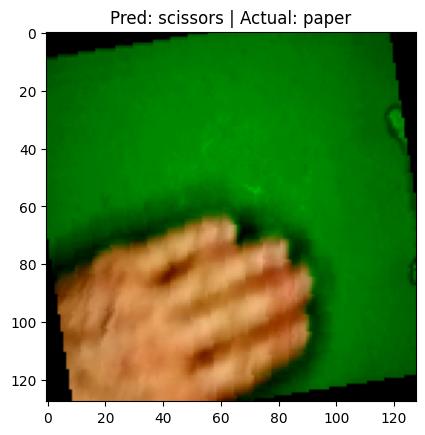

In [16]:
import matplotlib.pyplot as plt

model.eval()

wrong_images = []
wrong_preds = []
wrong_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(images)):
            if preds[i] != labels[i]:
                wrong_images.append(images[i])
                wrong_preds.append(preds[i])
                wrong_labels.append(labels[i])

# Show some wrong predictions
for i in range(min(10, len(wrong_images))):
    img = wrong_images[i].permute(1,2,0)
    plt.imshow(img)
    plt.title(f"Pred: {dataset.classes[wrong_preds[i]]} | Actual: {dataset.classes[wrong_labels[i]]}")
    plt.show()

In [17]:
torch.save(model.state_dict(), "model.pth")